In [1]:
import pandas as pd

df = pd.read_csv(
    '/Users/lgu/Desktop/ISWC2026-test/stream-performance-json2/time.tsv',
    sep='\t',
    header=None,
    names=["input_size", "format", "query_type", "TPs", "VARs", "VARs_ON_P", "SOL_P", "NODES", "BINDINGS", "EXECUTOR", "TIME"]
)

df = df[~df["TIME"].isin(["-", "T"])].copy()
df["TIME"] = pd.to_numeric(df["TIME"])


In [3]:
len(df[df["BINDINGS"] == 0])

375

In [4]:
df[["H", "K"]] = df["query_type"].str.extract(r"H=(\d+)_K=(\d+)").astype(int)

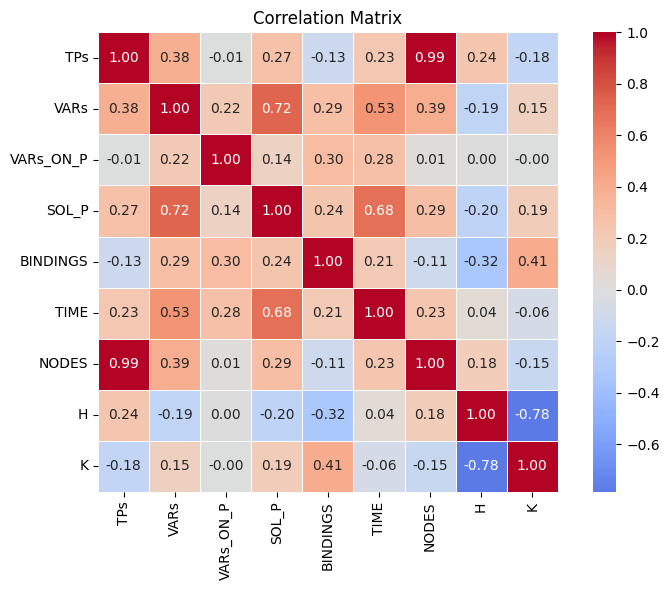

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["TPs", "VARs", "VARs_ON_P", "SOL_P", "BINDINGS", "TIME", "NODES", "H", "K"]
corr = df[cols].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


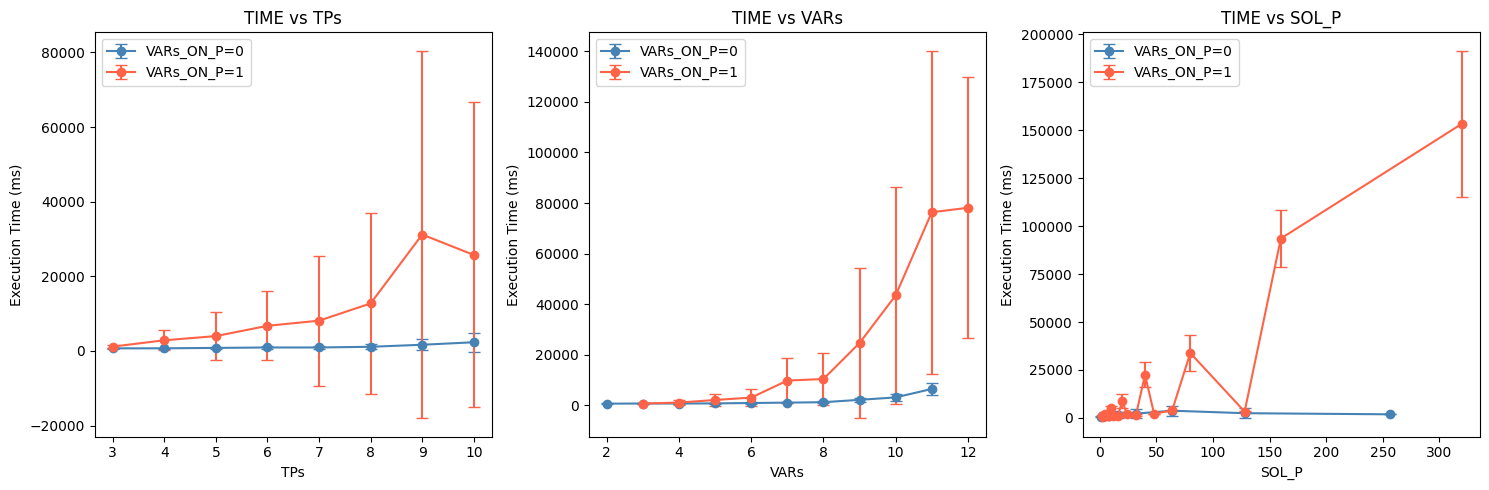

In [27]:
import matplotlib.pyplot as plt

factors = ["TPs", "VARs", "SOL_P"]
colors = {0: "steelblue", 1: "tomato"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, factor in zip(axes, factors):
    for var_on_p, group in df.groupby("VARs_ON_P"):
        stats = group.groupby(factor)["TIME"].agg(["mean", "std"]).reset_index()
        ax.errorbar(stats[factor], stats["mean"], yerr=stats["std"],
                    marker="o", capsize=4, color=colors[var_on_p],
                    label=f"VARs_ON_P={var_on_p}")
    ax.set_xlabel(factor)
    ax.set_ylabel("Execution Time (ms)")
    ax.set_title(f"TIME vs {factor}")
    ax.legend()

plt.tight_layout()
plt.show()